# Loading and inspecting MR Optimum output files

This notebook reads the example files in the repository's `data/` directory. It is designed for the `MRO` Python 3.11 environment and does not modify any data.

The files are generated by the synthetic SNR test and CLI run:

- `SNR.nii.gz` — the spatial SNR map. It is complex-valued internally, so the notebook displays its magnitude.
- `NC.nii.gz` — the coil noise covariance matrix. `NC.nii` is an uncompressed copy.
- `NCC.nii.gz` — the normalized coil noise-correlation coefficients.
- `fa90_example_slice.pkl` — a compact flip-angle-normalization example containing an SNR slice, a lower-resolution flip-angle map, and their geometry.

Run this notebook from the repository root (the folder containing `data/`). In VS Code, select the **MRO** kernel before running the cells.

In [3]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk

plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('data').resolve()
if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f'Cannot find {DATA_DIR}. Start the notebook from the repository root.'
    )

print(f'Data directory: {DATA_DIR}')
print(f'NumPy version: {np.__version__}')

Data directory: /Users/yuxin/Documents/NYU DS/NYU-DS/2026 Fall/capstone/chloe-mroptimum-tools/data
NumPy version: 2.1.3


## 1. Inventory the available files

This is a quick confirmation of which files are available before trying to load them. macOS metadata files such as `.DS_Store` are excluded.

In [8]:
for path in sorted(DATA_DIR.iterdir()):
    if path.name.startswith('.'):
        continue
    print(f'{path.name:28} {path.stat().st_size / 1024:9.1f} KiB')

NC.nii                             0.8 KiB
NC.nii.gz                          0.4 KiB
NCC.nii.gz                         0.4 KiB
SNR.nii.gz                        62.4 KiB
fa90_example_slice.pkl           528.7 KiB


## 2. Load NIfTI images

NIfTI is a medical-image format. SimpleITK returns array axes in `(slice, row, column)` order, while image spacing is reported in `(x, y, z)` order. The helper below prints both the stored array properties and the physical image geometry.

In [4]:
def read_nifti(filename):
    """Read a NIfTI file from data/ and return its SimpleITK image and NumPy array."""
    path = DATA_DIR / filename
    image = sitk.ReadImage(str(path))
    array = sitk.GetArrayFromImage(image)
    return image, array


def describe_image(filename):
    image, array = read_nifti(filename)
    values_for_display = np.abs(array) if np.iscomplexobj(array) else array
    print(f'File:        {filename}')
    print(f'Pixel type:  {image.GetPixelIDTypeAsString()}')
    print(f'Array shape: {array.shape}  (slice, row, column)')
    print(f'Dtype:       {array.dtype}')
    print(f'Spacing:     {image.GetSpacing()} mm  (x, y, z)')
    print(f'Origin:      {image.GetOrigin()}')
    print(f'Magnitude min/mean/max: {values_for_display.min():.4g} / '
          f'{values_for_display.mean():.4g} / {values_for_display.max():.4g}')
    return image, array

for filename in ('SNR.nii.gz', 'NC.nii.gz', 'NCC.nii.gz'):
    describe_image(filename)
    print()

File:        SNR.nii.gz
Pixel type:  complex of 32-bit float
Array shape: (1, 128, 128)  (slice, row, column)
Dtype:       complex64
Spacing:     (1.0, 1.0, 1.0) mm  (x, y, z)
Origin:      (0.0, 0.0, 0.0)
Magnitude min/mean/max: 2.365 / 6.412 / 16.67

File:        NC.nii.gz
Pixel type:  complex of 32-bit float
Array shape: (1, 8, 8)  (slice, row, column)
Dtype:       complex64
Spacing:     (1.0, 1.0, 1.0) mm  (x, y, z)
Origin:      (0.0, 0.0, 0.0)
Magnitude min/mean/max: 7.508e+04 / 2.749e+07 / 2.148e+08

File:        NCC.nii.gz
Pixel type:  64-bit float
Array shape: (1, 8, 8)  (slice, row, column)
Dtype:       float64
Spacing:     (1.0, 1.0, 1.0) mm  (x, y, z)
Origin:      (0.0, 0.0, 0.0)
Magnitude min/mean/max: -0.007909 / 0.126 / 1



## 3. Display the SNR map

SNR is dimensionless: a larger value means the reconstructed signal is large relative to estimated noise. The synthetic test uses a single slice. The display uses `abs(SNR)` because the file stores complex values, while visual interpretation normally uses magnitude.

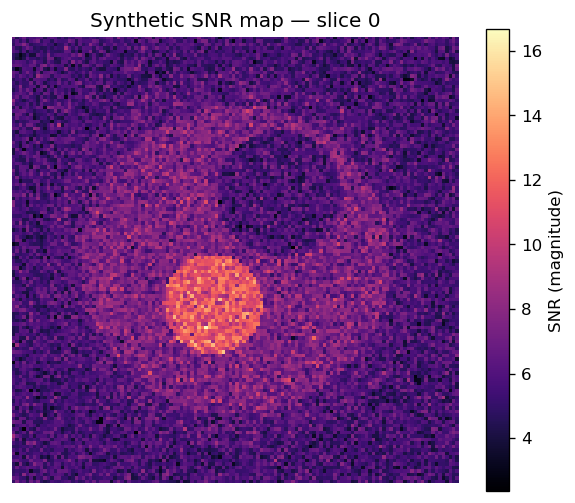

In [9]:
snr_image, snr = read_nifti('SNR.nii.gz')
snr_magnitude = np.abs(snr)
slice_number = snr_magnitude.shape[0] // 2

fig, ax = plt.subplots(figsize=(6, 5))
display = ax.imshow(snr_magnitude[slice_number], cmap='magma')
fig.colorbar(display, ax=ax, label='SNR (magnitude)')
ax.set_title(f'Synthetic SNR map — slice {slice_number}')
ax.set_axis_off()
plt.show()

## 4. Inspect coil-noise matrices

The covariance matrix (`NC`) summarizes the size and shared behavior of noise recorded by the eight simulated coils. The correlation matrix (`NCC`) scales those values to a comparable range: diagonal values are one because each coil is perfectly correlated with itself. Off-diagonal values near zero indicate little shared noise.

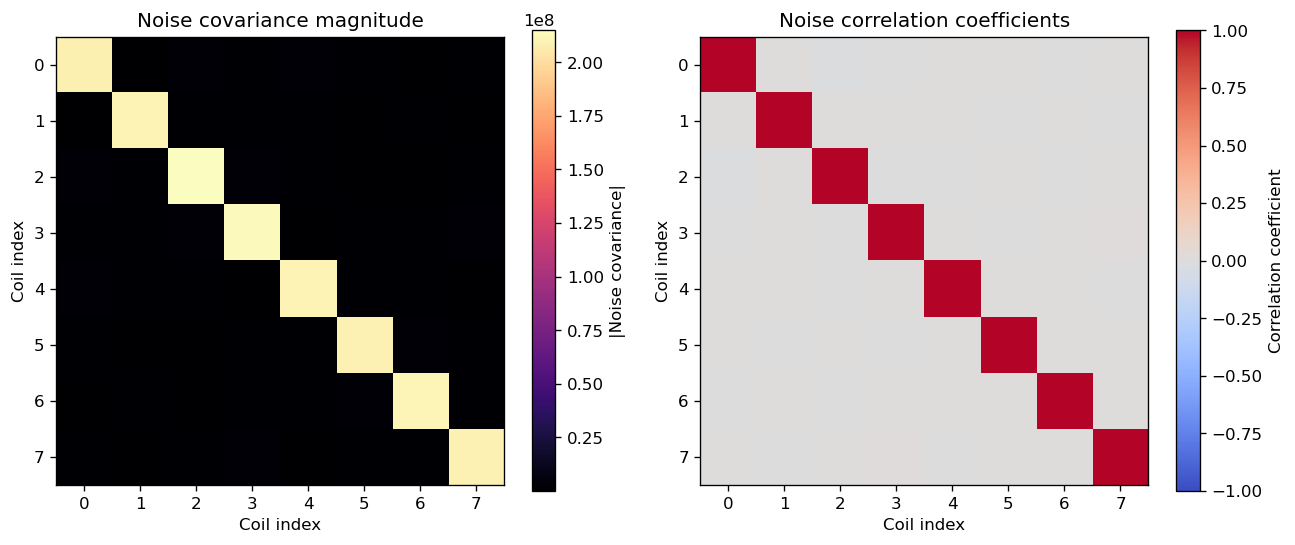

In [10]:
_, noise_covariance = read_nifti('NC.nii.gz')
_, noise_correlation = read_nifti('NCC.nii.gz')

# These are stored as one-slice 8 x 8 images.
noise_covariance = np.squeeze(noise_covariance)
noise_correlation = np.squeeze(noise_correlation)
coil_labels = np.arange(noise_covariance.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

covariance_plot = axes[0].imshow(np.abs(noise_covariance), cmap='magma')
fig.colorbar(covariance_plot, ax=axes[0], label='|Noise covariance|')
axes[0].set_title('Noise covariance magnitude')

correlation_plot = axes[1].imshow(
    noise_correlation.real, cmap='coolwarm', vmin=-1, vmax=1
)
fig.colorbar(correlation_plot, ax=axes[1], label='Correlation coefficient')
axes[1].set_title('Noise correlation coefficients')

for ax in axes:
    ax.set_xlabel('Coil index')
    ax.set_ylabel('Coil index')
    ax.set_xticks(coil_labels)
    ax.set_yticks(coil_labels)

plt.tight_layout()
plt.show()

## 5. Load the flip-angle example

The pickle stores a 256 × 256 complex SNR slice and a 64 × 64 flip-angle (FA) map in degrees. It was serialized by NumPy 2. The project currently uses NumPy 1.x for compatibility with `cmtools`, so the small loader below maps NumPy 2's internal pickle module name to its NumPy 1 equivalent. It does not alter the file.

Only open pickle files from trusted sources; pickles can execute code when loaded. This committed project file is trusted for this example.

In [6]:
class NumPy2CompatibleUnpickler(pickle.Unpickler):
    """Load this trusted NumPy-2 pickle while running NumPy 1.x."""

    def find_class(self, module, name):
        if module.startswith('numpy._core'):
            module = module.replace('numpy._core', 'numpy.core', 1)
        return super().find_class(module, name)


with (DATA_DIR / 'fa90_example_slice.pkl').open('rb') as file_handle:
    fa_example = NumPy2CompatibleUnpickler(file_handle).load()

print(f"Description: {fa_example['description']}")
print(f"SNR shape: {fa_example['snr'].shape}, dtype: {fa_example['snr'].dtype}")
print(f"FA shape:  {fa_example['fa_degrees'].shape}, dtype: {fa_example['fa_degrees'].dtype}")
print('SNR geometry:', fa_example['snr_geometry'])
print('FA geometry: ', fa_example['fa_geometry'])

Description: Product-coil validation slice for the mroptimum B-spline FA90 example
SNR shape: (256, 256, 1), dtype: complex64
FA shape:  (64, 64, 1), dtype: float32
SNR geometry: {'origin': (-4.7846832275390625, 156.93496704101562, 103.72969818115234), 'spacing': (1.171875, 1.171875, 10.0), 'direction': (-0.0, 0.0, -1.0, 0.0, -1.0, 0.0, -1.0, 0.0, 0.0)}
FA geometry:  {'origin': (-4.784698486328125, -143.06500244140625, -191.58248901367188), 'spacing': (4.6875, 4.6875, 10.0), 'direction': (-0.0, 0.0, -1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0)}


/var/folders/rq/08hnwn512ggb6d8tc7h6dzvw0000gn/T/ipykernel_99597/3361528059.py:7: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


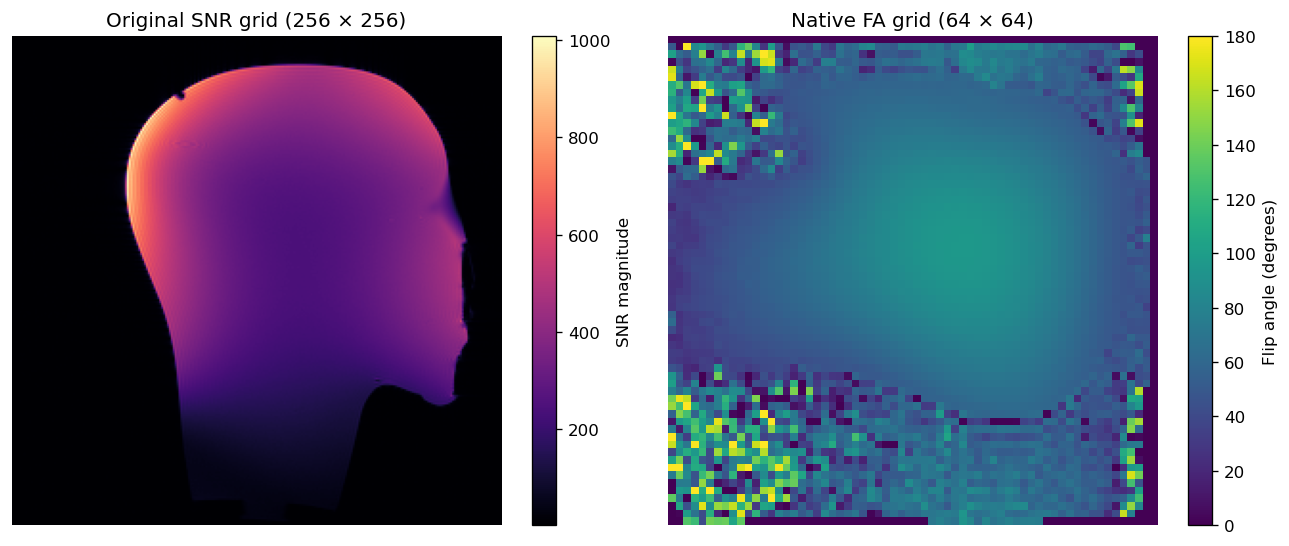

In [7]:
example_snr = np.squeeze(fa_example['snr'])
example_fa = np.squeeze(fa_example['fa_degrees'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

snr_plot = axes[0].imshow(np.abs(example_snr), cmap='magma')
fig.colorbar(snr_plot, ax=axes[0], label='SNR magnitude')
axes[0].set_title('Original SNR grid (256 × 256)')
axes[0].set_axis_off()

fa_plot = axes[1].imshow(example_fa, cmap='viridis', vmin=0, vmax=180)
fig.colorbar(fa_plot, ax=axes[1], label='Flip angle (degrees)')
axes[1].set_title('Native FA grid (64 × 64)')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## Next step

The FA map and SNR map intentionally have different grids. `mrotools.fa_normalization` resamples the FA map onto the SNR grid, then computes `SNR / sin(FA)` to estimate SNR normalized to a 90-degree flip angle. See `README.md` and `BEGINNER_GUIDE.md` for the command-line workflow.